# U23AI035 - LAB 10 - RAI

In [ ]:
import pandas as pd
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [ ]:
BASE_URL = "https://raw.githubusercontent.com/facebookresearch/SentEval/main/data/probing/"
TASKS = {
    "Length": BASE_URL + "sentence_length.txt",
    "Bigram Shift": BASE_URL + "bigram_shift.txt",
    "Subj Number": BASE_URL + "subj_number.txt"
}

def fetch_and_balance(url, num_samples=50000):
    response = requests.get(url)
    lines = response.text.strip().split('\n')
    data = []
    for line in lines:
        parts = line.split('\t')
        if len(parts) >= 3:
            data.append({'label': parts[1], 'text': parts[2]})
    
    df = pd.DataFrame(data)
    classes = df['label'].unique()
    samples_per_class = num_samples // len(classes)
    
    balanced_list = [resample(df[df['label'] == c], replace=False, 
                             n_samples=samples_per_class, random_state=42) for c in classes]
    return pd.concat(balanced_list).sample(frac=1, random_state=42)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True).to(device)
bert_model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def run_probing_experiment(task_name, url):
    print(f"\n--- Starting Task: {task_name} ---")
    df = fetch_and_balance(url)
    
    # 90:10 Split with class balance maintenance [cite: 4, 5]
    train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
    
    def get_embeddings(text_list):
        # We only need the 12 encoder layers [cite: 7]
        layers_data = [[] for _ in range(12)] 
        batch_size = 64
        
        for i in tqdm(range(0, len(text_list), batch_size)):
            batch = text_list[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=64).to(device)
            
            with torch.no_grad():
                outputs = bert_model(**inputs)
                # outputs.hidden_states[1] is Layer 1, [12] is Layer 12
                for l in range(1, 13):
                    cls_repr = outputs.hidden_states[l][:, 0, :].cpu().numpy()
                    layers_data[l-1].append(cls_repr)
        
        return [np.concatenate(l) for l in layers_data]

    print("Extracting BERT representations...")
    train_feats = get_embeddings(train_df['text'].tolist())
    test_feats = get_embeddings(test_df['text'].tolist())
    
    task_results = []
    for l_idx in range(12):
        clf = LogisticRegression(max_iter=500, solver='sag') # 'sag' is faster for large datasets
        clf.fit(train_feats[l_idx], train_df['label'])
        acc = accuracy_score(test_df['label'], clf.predict(test_feats[l_idx]))
        task_results.append(acc)
        print(f"Layer {l_idx+1} Accuracy: {acc:.4f}")
    
    return task_results


In [ ]:
final_results = {}
for name, url in TASKS.items():
    final_results[name] = run_probing_experiment(name, url)


--- Starting Task: Length ---
Extracting BERT representations...


100%|██████████| 79/79 [00:11<00:00,  7.03it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Layer 1 Accuracy: 0.8984


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Layer 2 Accuracy: 0.9262


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Layer 10 Accuracy: 0.8700


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Layer 11 Accuracy: 0.8504
Layer 12 Accuracy: 0.8410


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


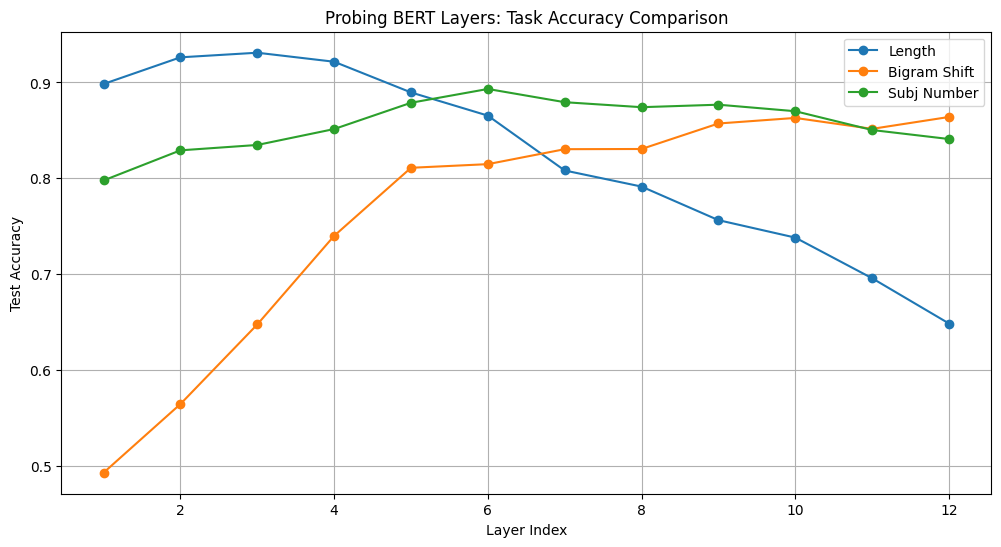

In [ ]:
plt.figure(figsize=(12, 6))
for name, scores in final_results.items():
    plt.plot(range(1, 13), scores, label=name, marker='o')

plt.title("Probing BERT Layers: Task Accuracy Comparison")
plt.xlabel("Layer Index")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("bert_probing_results.png", dpi=300, bbox_inches='tight')